# **Exploratory Data Analysis (EDA)**

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\medical-appointment-no-show-analytics\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\medical-appointment-no-show-analytics'



This section explores the cleaned medical appointments dataset to test the project hypotheses.

The visualisations were selected to:
- match the data type of each feature
- answer the business question clearly
- support later dashboard design
- provide evidence for hypothesis validation

Ethics note:
This analysis includes variables related to age, health, scholarship, and neighbourhood. These may reflect broader structural inequalities rather than purely individual behaviour, so findings are interpreted cautiously and at an aggregated level.

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Load cleaned dataset

The cleaned dataset produced in the ETL stage is loaded for exploratory analysis.

In [5]:
# Load cleaned dataset
df = pd.read_csv("data/processed/medical_appointments_cleaned.csv")

# Quick check to confirm data loaded correctly validate the shape and display the first few rows.
print("Shape:", df.shape)
display(df.head())

Shape: (110521, 22)


,Gender,scheduled_day,appointment_day,age,Neighbourhood,Scholarship,hypertension,Diabetes,Alcoholism,handicap,sms_received,no_show,scheduled_date,appointment_date,wait_days,scheduled_hour,scheduled_day_of_week,appointment_day_of_week,no_show_flag,has_handicap,same_day_appointment,row_id
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,18,Friday,Friday,0,0,1,0
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1,1
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1,2
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,17,Friday,Friday,0,0,1,3
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1,4


## Create analysis helper fields

A few grouped fields are created to make the hypothesis charts easier to interpret.

In [6]:
# Bucket raw age into analyst-friendly groups to compare no_show patterns by life stage.
age_bins = [-1, 17, 34, 49, 64, 120]
age_labels = ["0-17", "18-34", "35-49", "50-64", "65+"]
df["age_band"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# Group lead time into discrete ranges so rate charts are easier to read than raw day values.
wait_bins = [-1, 0, 3, 7, 14, 30, df["wait_days"].max()]
wait_labels = ["0 days", "1-3", "4-7", "8-14", "15-30", "31+"]
df["wait_band"] = pd.cut(df["wait_days"], bins=wait_bins, labels=wait_labels)

# Convert binary indicator columns to readable labels for plot legends and axis titles.
df["sms_label"] = df["sms_received"].map({0: "No SMS", 1: "SMS received"})
df["scholarship_label"] = df["Scholarship"].map({0: "No Scholarship", 1: "Scholarship"})
df["hypertension_label"] = df["hypertension"].map({0: "No Hypertension", 1: "Hypertension"})
df["diabetes_label"] = df["Diabetes"].map({0: "No Diabetes", 1: "Diabetes"})

# Force Monday-Saturday ordering to prevent alphabetical sorting in weekday visualizations.
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df["appointment_day_of_week"] = pd.Categorical(
    df["appointment_day_of_week"],
    categories=weekday_order,
    ordered=True
)

# Create a compact feature for number of chronic-condition indicators per patient.
df["chronic_condition_count"] = df["hypertension"] + df["Diabetes"]

# Preview transformed fields used by the hypothesis charts.
display(df[[
    "age", "age_band", "wait_days", "wait_band",
    "sms_label", "scholarship_label",
    "hypertension_label", "diabetes_label",
    "appointment_day_of_week", "chronic_condition_count"
]].head())

,age,age_band,wait_days,wait_band,sms_label,scholarship_label,hypertension_label,diabetes_label,appointment_day_of_week,chronic_condition_count
0,62,50-64,0,0 days,No SMS,No Scholarship,Hypertension,No Diabetes,Friday,1
1,56,50-64,0,0 days,No SMS,No Scholarship,No Hypertension,No Diabetes,Friday,0
2,62,50-64,0,0 days,No SMS,No Scholarship,No Hypertension,No Diabetes,Friday,0
3,8,0-17,0,0 days,No SMS,No Scholarship,No Hypertension,No Diabetes,Friday,0
4,56,50-64,0,0 days,No SMS,No Scholarship,Hypertension,Diabetes,Friday,2


## Helper function for no_show rate charts

This function creates rate-based bar charts rather than raw count charts.

This is useful because several categories have different group sizes, so no_show rate is more meaningful than appointment volume alone.

In [7]:
def plot_no_show_rate(data, group_col, title, order=None, horizontal=False, min_count=None):
    """
    Plot no-show rate (%) by a categorical field.

    Parameters:
    - data: source DataFrame
    - group_col: column to group by
    - title: chart title
    - order: optional custom sort order
    - horizontal: set True for horizontal bar chart
    - min_count: optional minimum number of appointments required per category
    """
    
    # Summarise group size and mean no_show rate
    summary = (
        data.groupby(group_col, observed=False)
        .agg(
            appointments=("no_show_flag", "size"),
            no_show_rate=("no_show_flag", "mean")
        )
        .reset_index()
    )
    
    # Optional filter to remove very small categories
    if min_count is not None:
        summary = summary[summary["appointments"] >= min_count].copy()
    
    # Convert to percentage for readability
    summary["no_show_rate_pct"] = summary["no_show_rate"] * 100
    
    # Apply manual order if provided
    if order is not None:
        summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
        summary = summary.sort_values(group_col)
    else:
        summary = summary.sort_values("no_show_rate_pct", ascending=not horizontal)
    
    # Create plot
    plt.figure(figsize=(10, 5))
    
    if horizontal:
        ax = sns.barplot(data=summary, x="no_show_rate_pct", y=group_col)
        ax.set_xlabel("No-show rate (%)")
        ax.set_ylabel(group_col.replace("_", " ").title())
        
        # Add labels to bars
        for i, row in summary.reset_index(drop=True).iterrows():
            ax.text(
                row["no_show_rate_pct"] + 0.3,
                i,
                f'{row["no_show_rate_pct"]:.1f}% (n={row["appointments"]})',
                va="center"
            )
    else:
        ax = sns.barplot(data=summary, x=group_col, y="no_show_rate_pct")
        ax.set_xlabel(group_col.replace("_", " ").title())
        ax.set_ylabel("No-show rate (%)")
        
        # Add labels to bars
        for i, row in summary.reset_index(drop=True).iterrows():
            ax.text(
                i,
                row["no_show_rate_pct"] + 0.3,
                f'{row["no_show_rate_pct"]:.1f}%\n(n={row["appointments"]})',
                ha="center",
                va="bottom",
                fontsize=9
            )
    
    plt.title(title)
    plt.xticks(rotation=45 if not horizontal else 0)
    plt.tight_layout()
    plt.show()
    
    return summary

---

## Hypothesis Exploration

### Hypothesis 1: Lead Time Impact

**Business question:**  
Are patients with longer wait times between booking and appointment more likely to miss their appointment?

**Feature(s):**
- `wait_days` or derived wait-time feature (type: numeric)
- `No_show` (type: categorical)

**Null hypothesis (H0):**  
There is no difference in no_show behaviour between appointments with shorter and longer waiting times.

**Alternative hypothesis (H1):**  
Patients with longer waiting times are more likely to be no_shows.

**EDA approach (why this chart):**
Because waiting time is numeric and no-show status is categorical, a boxplot is appropriate for comparing distributions, while a wait-band bar chart makes the no-show pattern easier to interpret.

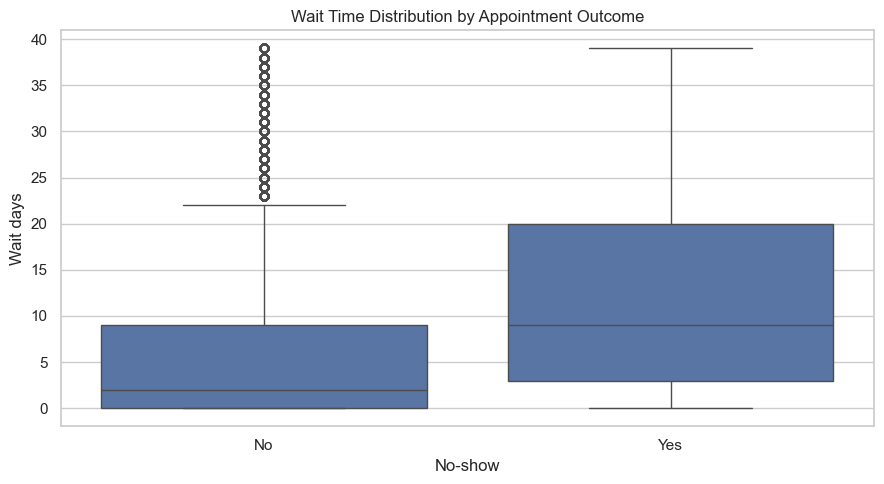

In [8]:
# Boxplot of wait time by attendance status
# Filtering to the 95th percentile improves readability by reducing extreme outlier stretch
wait_cap = df["wait_days"].quantile(0.95)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df[df["wait_days"] <= wait_cap],
    x="no_show",
    y="wait_days"
)
plt.title("Wait Time Distribution by Appointment Outcome")
plt.xlabel("No-show")
plt.ylabel("Wait days")
plt.tight_layout()
plt.show()

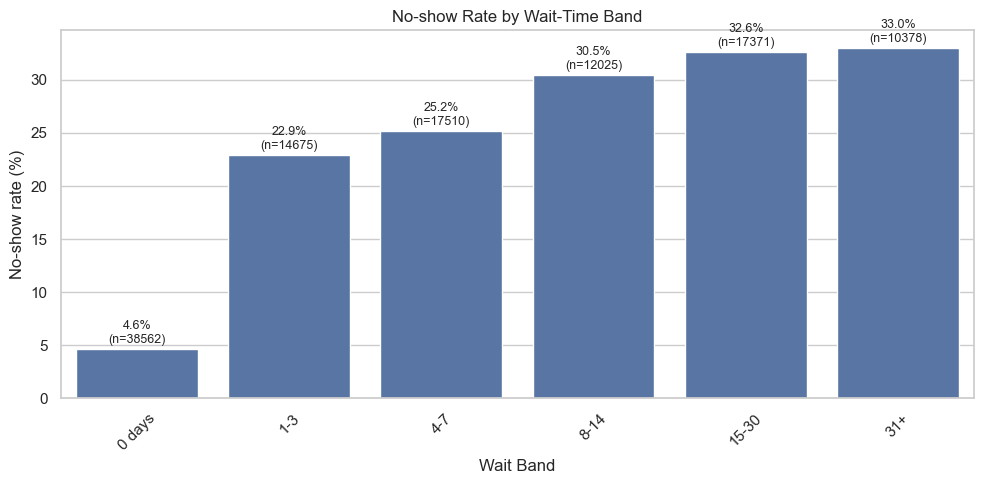

,wait_band,appointments,no_show_rate,no_show_rate_pct
0,0 days,38562,0.046471,4.647062
1,1-3,14675,0.228893,22.889267
2,4-7,17510,0.252027,25.202741
3,8-14,12025,0.304699,30.469854
4,15-30,17371,0.325888,32.588797
5,31+,10378,0.330025,33.002505


In [9]:
# No-show rate by wait-time band
h1_summary = plot_no_show_rate(
    data=df,
    group_col="wait_band",
    title="No-show Rate by Wait-Time Band",
    order=["0 days", "1-3", "4-7", "8-14", "15-30", "31+"]
)

display(h1_summary)

The boxplot shows that appointments ending in a no_show generally have longer waiting times than appointments that were attended, with a noticeably higher median and wider spread. This pattern is reinforced by the wait-band chart, where the no_show rate rises from 4.6% for same-day appointments to 22.9% for 1–3 days, 25.2% for 4–7 days, 30.5% for 8–14 days, 32.6% for 15–30 days, and 33.0% for 31+ days. Overall, this provides strong visual support for the alternative hypothesis that longer waiting times are associated with a greater likelihood of missing an appointment. From a business perspective, reducing long delays between booking and appointment may be one of the clearest ways to improve attendance. Ethically, this finding should be framed as a possible service design or access issue rather than simply blaming patients for missed appointments.

**Result:** The alternative hypothesis is supported.

### Hypothesis 2: Reminder Effect

**Business question:**  
Do SMS reminders appear to reduce the likelihood of a patient missing their appointment?

**Feature(s):**
- `SMS_received` (type: categorical)
- `no_show` (type: categorical)

**Null hypothesis (H0):**  
There is no association between receiving an SMS reminder and no_show status.

**Alternative hypothesis (H1):**  
SMS reminder status is associated with different no_show rates.

**EDA approach (why this chart):**  
Because both variables are categorical, a stacked bar chart or grouped bar chart is appropriate to compare no_show rates for patients who did and did not receive an SMS reminder.

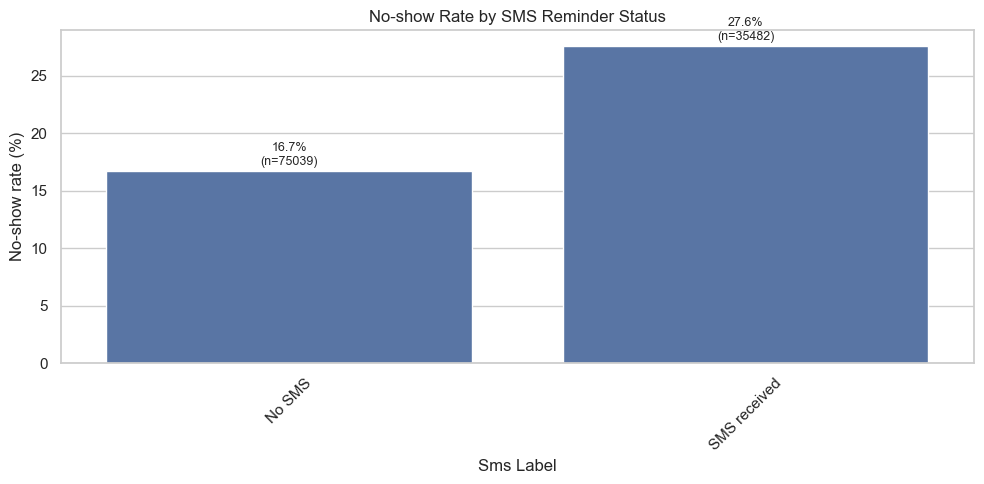

,sms_label,appointments,no_show_rate,no_show_rate_pct
0,No SMS,75039,0.166980,16.697984
1,SMS received,35482,0.275745,27.574545


In [10]:
# No-show rate by SMS reminder status
h2_summary = plot_no_show_rate(
    data=df,
    group_col="sms_label",
    title="No-show Rate by SMS Reminder Status",
    order=["No SMS", "SMS received"]
)

display(h2_summary)

The chart shows that appointments where an SMS reminder was received had a higher no_show rate (27.6%, n=35,482) than appointments with no SMS recorded (16.7%, n=75,039). This means the visual does not support the original hypothesis that SMS reminders reduce no_shows. However, the result should be interpreted cautiously, because SMS receipt may be linked to other factors such as longer waiting times or higher-risk bookings rather than the reminder itself causing poorer attendance. From a business perspective, this suggests that reminder status on its own is not enough to explain no_show behaviour and should be considered alongside other variables such as wait time. Ethically, it is important not to treat this relationship as proof of causation.

**Result:** The alternative hypothesis is not supported.

### Hypothesis 3: Age Demographics

**Business question:**  
Do no_show rates vary across age groups, with younger adults more likely to miss appointments?

**Feature(s):**
- `Age` or derived `age_band` (type: numeric / categorical if grouped)
- `no_show` (type: categorical)

**Null hypothesis (H0):**  
There is no association between patient age and no_show status.

**Alternative hypothesis (H1):**  
no_show rates differ by age group, with younger adults more likely to miss appointments than older patients.

**EDA approach (why this chart):**  
Because age can be analysed as either numeric or grouped categorical data, a histogram can show age distribution and a bar chart by age band can compare no_show rates across groups.

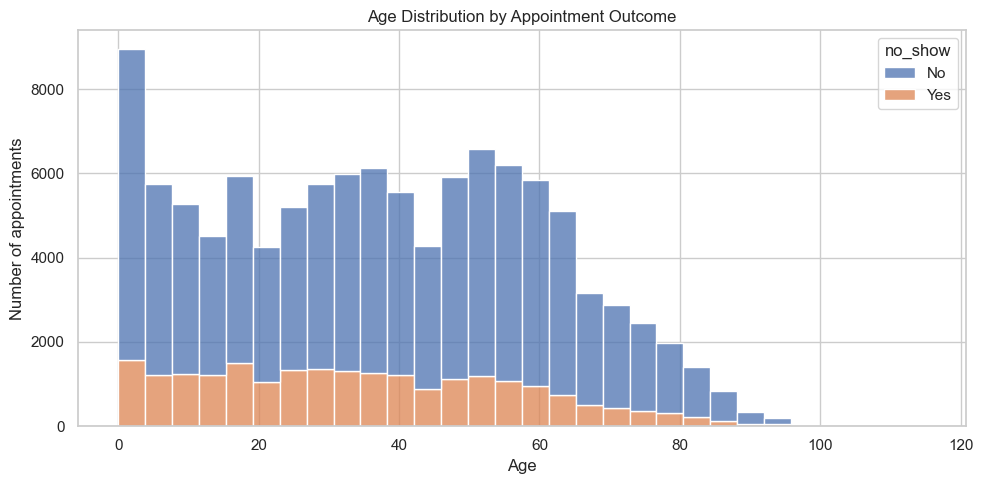

In [11]:
# Age distribution split by no-show status
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="age",
    hue="no_show",
    bins=30,
    multiple="stack"
)
plt.title("Age Distribution by Appointment Outcome")
plt.xlabel("Age")
plt.ylabel("Number of appointments")
plt.tight_layout()
plt.show()

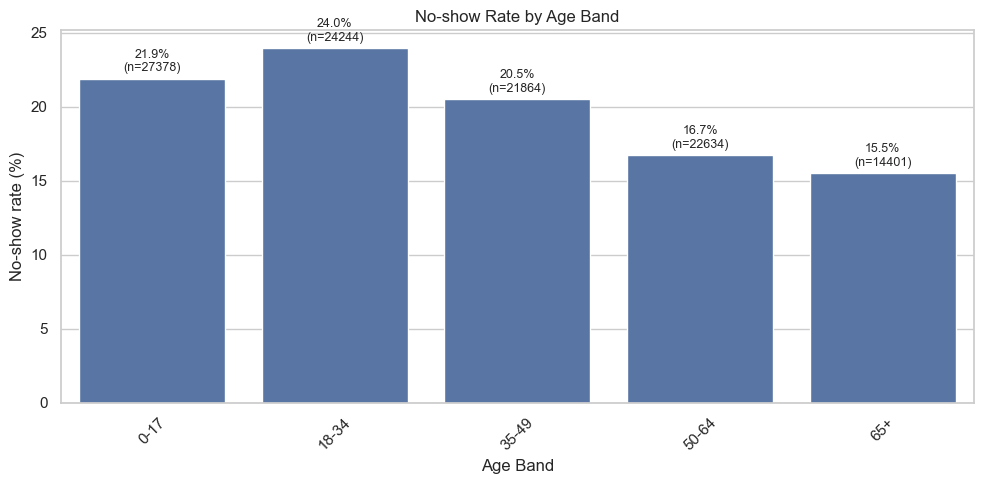

,age_band,appointments,no_show_rate,no_show_rate_pct
0,0-17,27378,0.219008,21.900796
1,18-34,24244,0.239729,23.972942
2,35-49,21864,0.205315,20.531467
3,50-64,22634,0.167226,16.722630
4,65+,14401,0.154989,15.498924


In [12]:
# No-show rate by age band
h3_summary = plot_no_show_rate(
    data=df,
    group_col="age_band",
    title="No-show Rate by Age Band",
    order=["0-17", "18-34", "35-49", "50-64", "65+"]
)

display(h3_summary)

The histogram shows that appointments are concentrated in younger and middle-age groups, with a clear spike at age 0, which is likely to represent infants recorded as zero years old. The age-band chart shows the highest no_show rate for patients aged 18–34 (24.0%), followed by 0–17 (21.9%) and 35–49 (20.5%), while the rates fall for older groups, with 50–64 at 16.7% and 65+ at 15.5%. This provides moderate support for the alternative hypothesis that younger patients, especially young adults, are more likely to miss appointments than older patients. From a business perspective, this suggests that younger age groups may benefit from more flexible scheduling or stronger reminder strategies. Ethically, these results should be described as patterns in the data rather than stereotypes about age groups.

**Result:** The alternative hypothesis is supported.

### Hypothesis 4: Temporal Patterns

**Business question:**  
Are appointments on certain weekdays associated with higher no_show rates than others?

**Feature(s):**
- derived `appointment_weekday` (type: categorical)
- `no_show` (type: categorical)

**Null hypothesis (H0):**  
There is no association between appointment weekday and no_show status.

**Alternative hypothesis (H1):**  
No-show rates vary by appointment weekday.

**EDA approach (why this chart):**  
Because weekday and no_show status are both categorical, a bar chart is appropriate to compare no_show rates across days of the week.

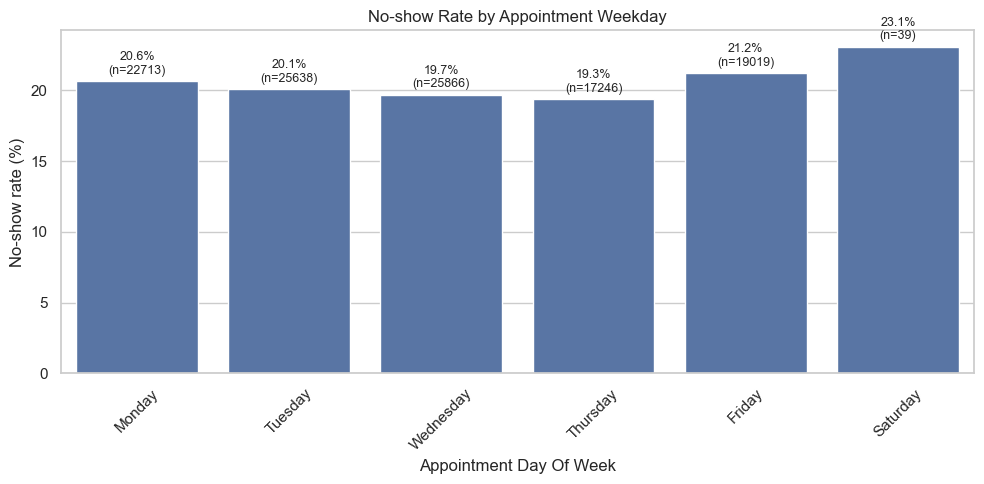

,appointment_day_of_week,appointments,no_show_rate,no_show_rate_pct
0,Monday,22713,0.206446,20.644565
1,Tuesday,25638,0.200874,20.087370
2,Wednesday,25866,0.196861,19.686074
3,Thursday,17246,0.193494,19.349414
4,Friday,19019,0.212261,21.226142
5,Saturday,39,0.230769,23.076923


In [13]:
# No-show rate by appointment weekday
h4_summary = plot_no_show_rate(
    data=df,
    group_col="appointment_day_of_week",
    title="No-show Rate by Appointment Weekday",
    order=weekday_order
)

display(h4_summary)

The weekday chart shows that no_show rates are fairly similar across Monday to Friday, ranging from 19.3% on Thursday to 21.2% on Friday. Saturday has the highest rate at 23.1%, but this is based on only 39 appointments, so it is too small to compare reliably with the other days. Overall, this provides only limited support for the alternative hypothesis, as there is no strong weekday effect across the main working week and the differences are relatively small. From a business perspective, appointment day alone does not appear to be as important as factors such as wait time or age. Ethically, any weekday differences should be interpreted carefully because they may reflect clinic scheduling patterns or access constraints rather than patient choice alone.

**Result:** The alternative hypothesis is only weakly supported.

### Hypothesis 5: Socio-economic / Access Factors

**Business question:**  
Do patients with indicators of greater socioeconomic or access-related disadvantage have different no_show rates?

**Feature(s):**
- `Scholarship` (type: categorical)
- `Neighbourhood` (type: categorical)
- `no_show` (type: categorical)

**Null hypothesis (H0):**  
There is no association between `Scholarship` status or `Neighbourhood` and no_show status.

**Alternative hypothesis (H1):**  
`Scholarship` status and/or `Neighbourhood` are associated with different no_show rates.

**EDA approach (why this chart):**  
Because these are categorical features, bar charts are appropriate for `Scholarship` and a sorted bar chart or heatmap can be used to compare no_show rates across neighbourhoods.

#### Hypothesis 5a: Scholarship

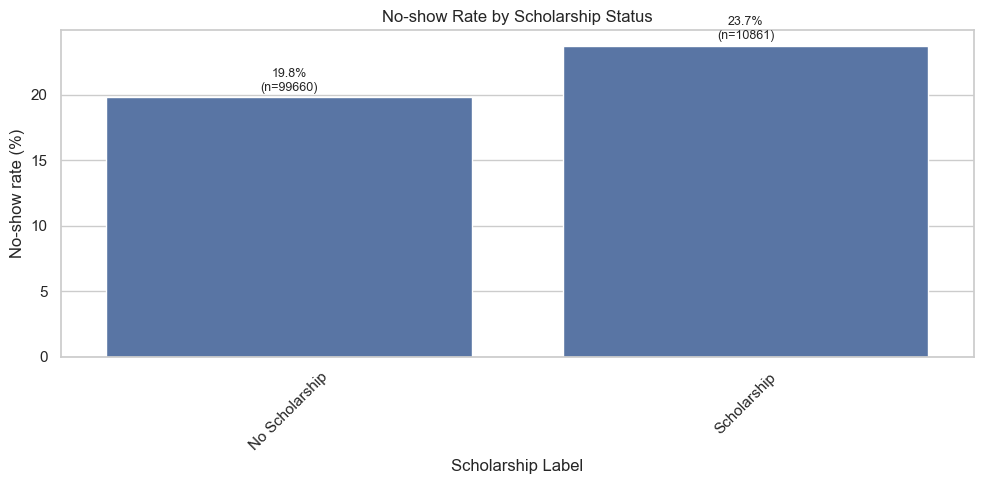

,scholarship_label,appointments,no_show_rate,no_show_rate_pct
0,No Scholarship,99660,0.198033,19.803331
1,Scholarship,10861,0.237363,23.736304


In [14]:
# No-show rate by scholarship status
h5a_summary = plot_no_show_rate(
    data=df,
    group_col="scholarship_label",
    title="No-show Rate by Scholarship Status",
    order=["No Scholarship", "Scholarship"]
)

display(h5a_summary)

The chart shows that patients with a scholarship have a higher no_show rate (23.7%) than patients without a scholarship (19.8%). This supports the alternative hypothesis that scholarship status is linked to appointment attendance. It may suggest that wider socioeconomic or access-related issues are affecting whether some patients are able to attend.

#### Hypothesis 5b: Neighbourhood

Because `Neighbourhood` contains many categories, plotting all groups in a single chart reduced readability.  
To improve interpretability, the analysis was limited to neighbourhoods with at least 500 appointments and the chart focuses on the groups with the highest no_show rates.

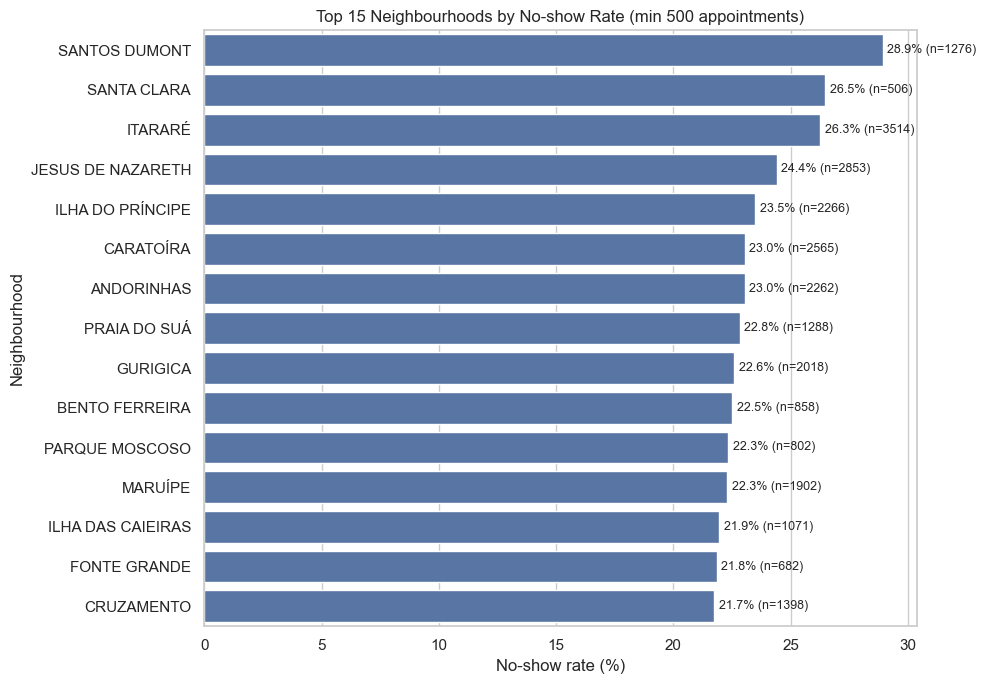

In [15]:
# Summarise neighbourhood performance
neighbourhood_summary = (
    df.groupby("Neighbourhood")
    .agg(
        appointments=("no_show_flag", "size"),
        no_show_rate=("no_show_flag", "mean")
    )
    .reset_index()
)

# Keep only neighbourhoods with a reasonable number of appointments
neighbourhood_summary = neighbourhood_summary[neighbourhood_summary["appointments"] >= 500].copy()

# Convert rate to percentage
neighbourhood_summary["no_show_rate_pct"] = neighbourhood_summary["no_show_rate"] * 100

# Sort descending and keep top 15
top_15_neighbourhoods = neighbourhood_summary.sort_values(
    "no_show_rate_pct", ascending=False
).head(15)

# Plot
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=top_15_neighbourhoods,
    x="no_show_rate_pct",
    y="Neighbourhood"
)

plt.title("Top 15 Neighbourhoods by No-show Rate (min 500 appointments)")
plt.xlabel("No-show rate (%)")
plt.ylabel("Neighbourhood")

# Add labels
for i, row in top_15_neighbourhoods.reset_index(drop=True).iterrows():
    ax.text(
        row["no_show_rate_pct"] + 0.2,
        i,
        f'{row["no_show_rate_pct"]:.1f}% (n={row["appointments"]})',
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

The neighbourhood chart shows that no_show rates vary across different areas, with the highest filtered rates seen in Santos Dumont (28.9%), Santa Clara (26.5%), and Itararé (26.3%). This supports the alternative hypothesis that neighbourhood is associated with no_show behaviour. These differences should still be interpreted carefully, as neighbourhood may reflect wider social or access issues rather than individual choice.

**Result:** The alternative hypothesis is supported.

### Hypothesis 6: Health Profile

**Business question:**  
Do patients with chronic health conditions show different attendance patterns compared with patients without those conditions?

**Feature(s):**
- `Hypertension` (type: categorical)
- `Diabetes` (type: categorical)
- `no_show` (type: categorical)

**Null hypothesis (H0):**  
There is no association between chronic condition indicators and no_show status.

**Alternative hypothesis (H1):**  
Patients with chronic conditions such as hypertension or diabetes have different no_show rates from those without these conditions.

**EDA approach (why this chart):**  
Because both condition indicators and no_show status are categorical, grouped bar charts are appropriate to compare no_show rates between patients with and without each condition.

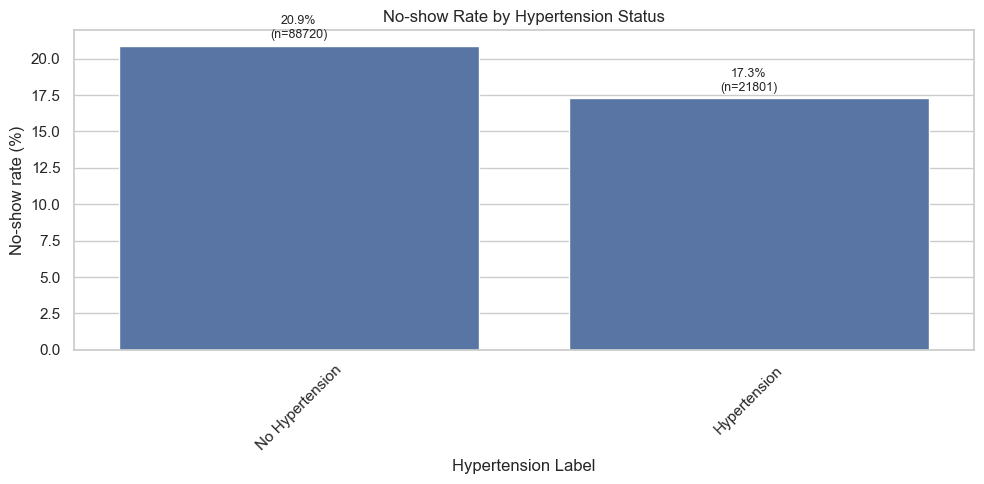

,hypertension_label,appointments,no_show_rate,no_show_rate_pct
1,No Hypertension,88720,0.208995,20.899459
0,Hypertension,21801,0.173020,17.301959


In [16]:
# No-show rate by hypertension status
h6a_summary = plot_no_show_rate(
    data=df,
    group_col="hypertension_label",
    title="No-show Rate by Hypertension Status",
    order=["No Hypertension", "Hypertension"]
)

display(h6a_summary)

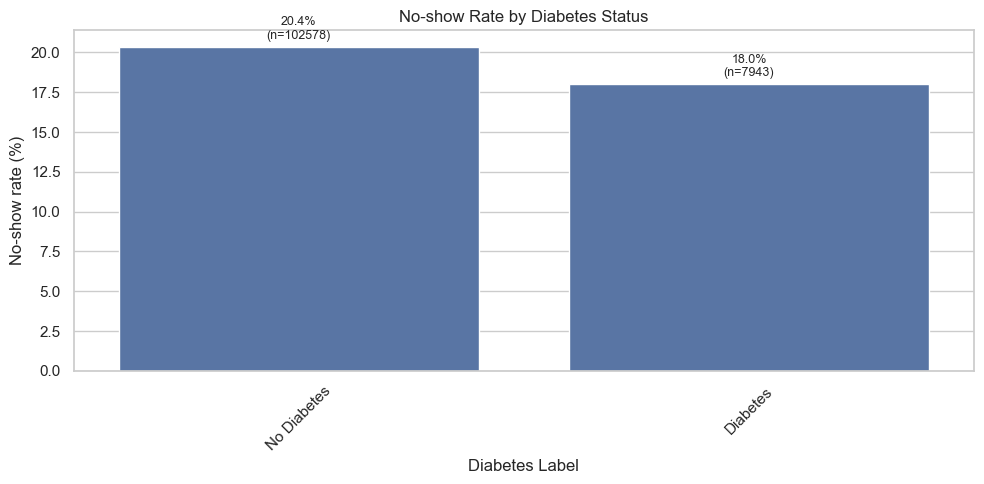

,diabetes_label,appointments,no_show_rate,no_show_rate_pct
1,No Diabetes,102578,0.203591,20.359141
0,Diabetes,7943,0.180033,18.003273


In [17]:
# No-show rate by diabetes status
h6b_summary = plot_no_show_rate(
    data=df,
    group_col="diabetes_label",
    title="No-show Rate by Diabetes Status",
    order=["No Diabetes", "Diabetes"]
)

display(h6b_summary)

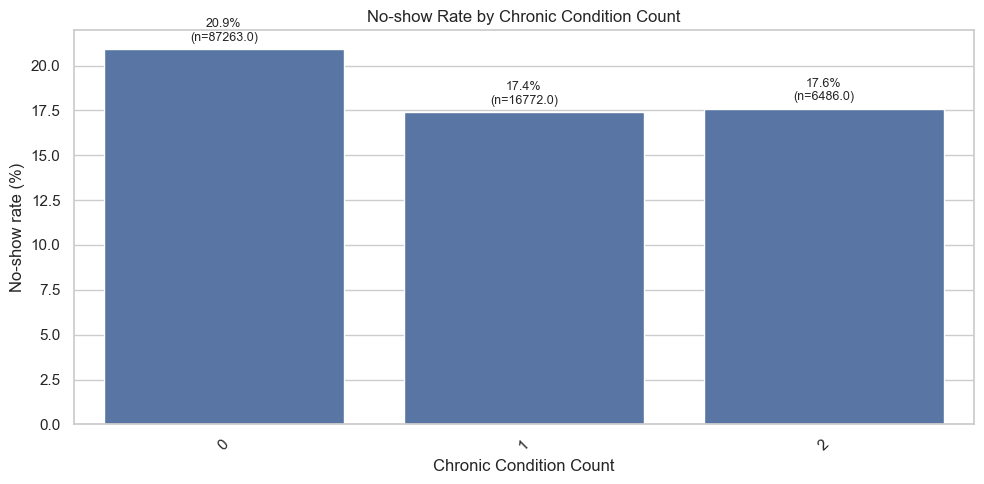

,chronic_condition_count,appointments,no_show_rate,no_show_rate_pct
0,0,87263,0.209172,20.917227
1,1,16772,0.174100,17.409969
2,2,6486,0.175917,17.591736


In [18]:
#combined chronic condition count
h6c_summary = plot_no_show_rate(
    data=df,
    group_col="chronic_condition_count",
    title="No-show Rate by Chronic Condition Count",
    order=[0, 1, 2]
)#

display(h6c_summary)

The health profile analysis shows that patients with chronic conditions actually have lower no_show rates than patients without those conditions. Patients with hypertension have a no_show rate of 17.3% compared with 20.9% for patients without hypertension, while patients with diabetes have a no_show rate of 18.0% compared with 20.4% for patients without diabetes. A combined chronic-condition count shows the same pattern, with patients who have no listed condition at 20.9%, compared with 17.4% for one condition and 17.6% for two conditions. This supports the alternative hypothesis only in the sense that attendance patterns do differ by health profile, but the direction is the opposite of any expectation that chronic conditions would lead to more missed appointments. From a business perspective, this may suggest that patients managing chronic conditions are more engaged with ongoing care. Ethically, health-related data is sensitive and should be discussed only in aggregated terms without making assumptions about individual patients.

**Result:** The alternative hypothesis is supported, but in the opposite direction to expectation.

---

## Correlation heatmap

This is not a direct hypothesis test, but it is useful for spotting numeric relationships and preparing for the modelling stage.

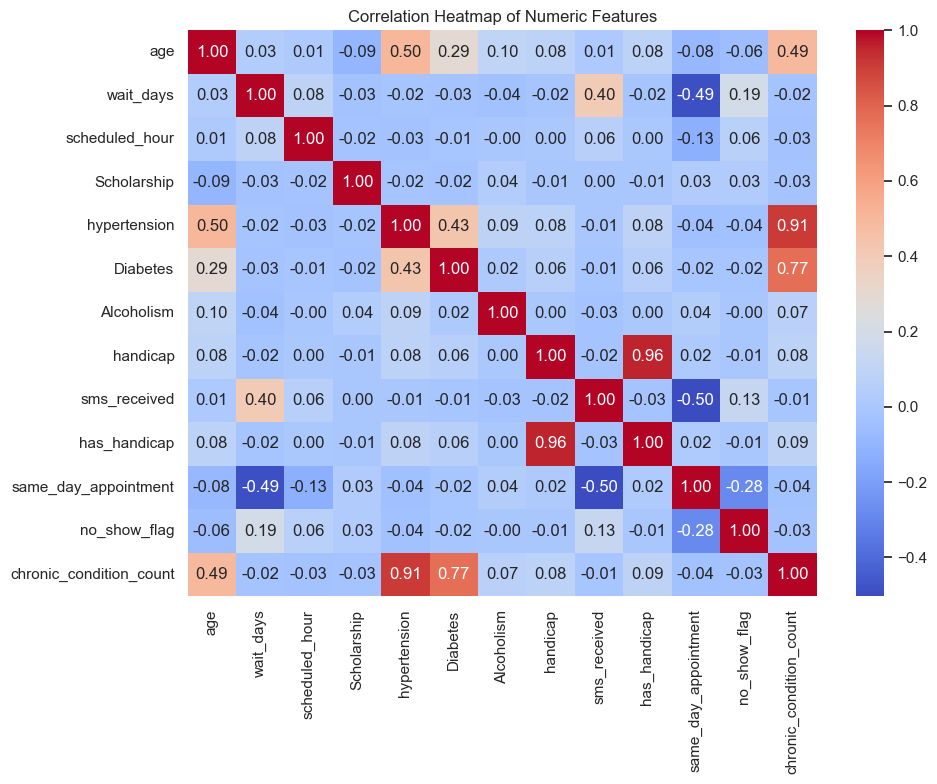

In [19]:
# Correlation heatmap for numeric fields
numeric_cols = [
    "age", "wait_days", "scheduled_hour",
    "Scholarship", "hypertension", "Diabetes",
    "Alcoholism", "handicap", "sms_received",
    "has_handicap", "same_day_appointment",
    "no_show_flag", "chronic_condition_count"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

The correlation heatmap shows that `wait_days` has one of the clearest positive relationships with `no_show_flag` (0.19), while `same_day_appointment` has a stronger negative relationship (-0.28). This supports the earlier EDA finding that shorter waiting times are linked to better attendance.

The heatmap also shows that `sms_received` is positively correlated with `wait_days` (0.40), suggesting that reminder status may partly reflect longer booking delays rather than acting as an independent explanation of no_show behaviour. In addition, age is moderately correlated with health variables such as hypertension and chronic condition count, which suggests that some health-related patterns may partly reflect age differences in the patient population.

Overall, the heatmap is useful for identifying broad numeric relationships and possible feature overlap before modelling, but the correlations are mostly weak to moderate and should not be interpreted as proof of causation.

---

## EDA summary

The exploratory analysis tested six hypotheses to identify the main factors associated with appointment no-shows. The strongest and most consistent finding was that longer waiting times are linked to higher no-show rates, making wait-related features some of the most important variables in the dataset.

The analysis also found meaningful variation across age band, scholarship status, neighbourhood, and health profile, while weekday effects were relatively small. SMS reminder status showed an unexpected pattern, with higher no-show rates among appointments where an SMS was recorded, but this is likely to reflect overlapping factors such as longer waiting times rather than a direct reminder effect.

Taken together, the EDA suggests that no-show behaviour is shaped by a mix of timing, access, and patient context rather than any single variable alone. These findings provide a clear basis for the modelling stage, where the most relevant and least redundant features will be selected for predictive analysis.

These findings are interpreted cautiously, as variables such as scholarship, neighbourhood, age, and health profile may reflect wider structural inequalities or access barriers rather than purely individual behaviour.